Neural Network Basics
Input Layer: Receives the input features/data fed into the neural network.
Hidden Layer: Processes inputs and learns patterns using weights, biases, and activation functions.
Output Layer: Produces the final prediction or classification result.
Weights & Biases: Weights determine the importance of each input, while biases shift the neuron's output. Both are learned during training.
Forward Propagation: The process of passing inputs through the network layer-by-layer to obtain a prediction.
Loss Function: Measures the difference between the predicted and actual values. The model aims to minimize the loss during training.
Activation Functions
ReLU: f(x) = max(0, x) — Outputs 0 for negative values and the input for positive values. Commonly used in hidden layers. Pros: Fast and reduces vanishing-gradient problems. Cons: Can cause "dying" neurons.

Sigmoid: f(x) = 1/(1 + e⁻ˣ) — Converts values to a range of 0–1. Commonly used for binary classification. Pros: Probability-like output. Cons: Can suffer from vanishing gradients.

Tanh: Maps values to −1 to +1. Used mainly in some hidden/recurrent layers. Pros: Zero-centered. Cons: Can suffer from vanishing gradients.

Softmax: Converts multiple outputs into probabilities that sum to 1. Used mainly for multi-class classification. Pros: Gives class probabilities. Cons: Best suited to mutually exclusive classes

### Install tensorflow

In [1]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 1.2 MB/s eta 0:05:04
   ---------------------------------------- 0.5/351.2 MB 1.2 MB/s eta 0:05:04
   ---------------------------------------- 0.8/351.2 MB 1.1 MB/s eta 0:05:33
   ---------------------------------------- 1.3/351.2 MB 1.3 MB/s eta 0:04:30
   ---------------------------------------- 1.6/351.2 MB 1.4 MB/s eta 0:04:18
   ---------------------------------------- 2.1/351.2 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 2.4/351.2 MB 1.5 MB/s eta 0:03:53
   ---------------------------------------- 2.6/351.2 MB 1.5 MB/s eta 0:03:47
   ---------------------------------------- 2.9/351.2 MB 1.4 MB/s eta 0:04:15
   ---------------------------------------- 3.1/351.2 MB 1.4 MB/s eta 0:04:14
   ----

### Load the Iris dataset

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

print(X.shape, y.shape)
print(iris.target_names)

(150, 4) (150,)
['setosa' 'versicolor' 'virginica']


### Preprocess the data

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_cat = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42)

### Build the neural network

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\USER\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [7]:
history = model.fit(X_train, y_train, epochs=30, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3250 - loss: 1.2106 - val_accuracy: 0.3000 - val_loss: 1.1737
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4583 - loss: 1.0855 - val_accuracy: 0.6333 - val_loss: 1.0601
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.9851 - val_accuracy: 0.7000 - val_loss: 0.9545
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7833 - loss: 0.8925 - val_accuracy: 0.8333 - val_loss: 0.8646
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7833 - loss: 0.8179 - val_accuracy: 0.9000 - val_loss: 0.7822
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7833 - loss: 0.7490 - val_accuracy: 0.9333 - val_loss: 0.7126
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7833 - loss: 0.6901 - val_accuracy: 0.9000 - val_loss: 0.6507
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.6388 - val_accuracy: 0.9000 - va

### Evaluation + Plot Accuracy

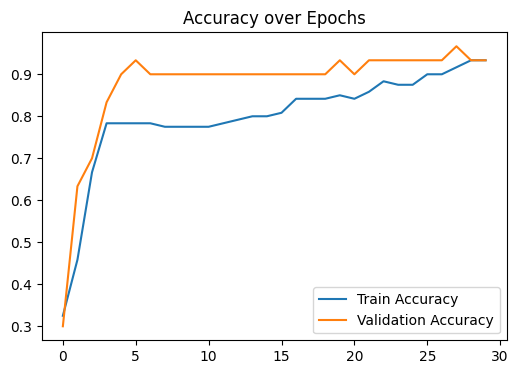

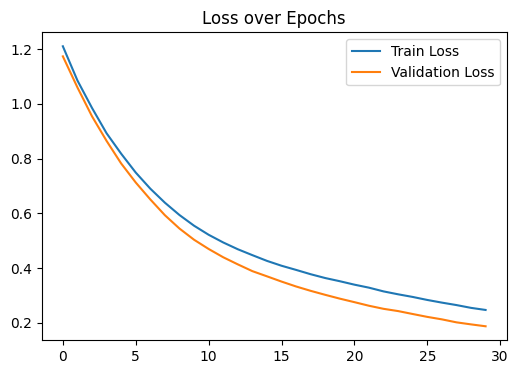

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

### Accuracy Check

In [12]:
print(history.history['accuracy'][-1])

print(history.history['val_accuracy'][-1])

0.9333333373069763
0.9333333373069763


Model Interpretation:
Both training and validation loss decreased steadily and closely together across all 30 epochs, with validation loss actually settling slightly lower than training loss. This indicates the model generalized well to unseen data without overfitting. Given the small size and simplicity of the Iris dataset, this strong performance is expected — the three flower species are fairly well separated by the four input features (sepal/petal length and width).